In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

In [ ]:
import pandas as pd

In [ ]:
import sys
sys.path.append("/home/563/as8561/side_projects/extreme_el_nino_2026/")

In [5]:
from functions import preproc_funcs as funcs

In [ ]:
# xr.open_dataset('/g/data/**/replicas/CMIP6/CMIP/**/**/historical/r10i1p1f1/Amon/ts/gn/**/*.nc')
# xr.open_dataset('/g/data/**/replicas/CMIP6/CMIP/**/**/piControl/r1i1p1f1/Amon/ts/gn/**/*.nc')
# xr.open_dataset('/g/data/**/replicas/CMIP6/ScenarioMIP/**/**/ssp585/r10i1p1f1/Amon/tas/gn/**/*.nc')
# xr.open_dataset('/g/data/**/replicas/CMIP6/CMIP/**/**/abrupt-4xCO2/r1i1p1f1/Amon/ts/gn/**/*.nc')

In [7]:
import gzip
from pathlib import Path


In [ ]:
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],

    # --- type sizes: consistent hierarchy (title > labels > ticks/legend) ---
    "font.size":        9,
    "axes.titlesize":   11,
    "axes.labelsize":   10,
    "xtick.labelsize":  9,
    "ytick.labelsize":  9,
    "legend.fontsize":  9,
    "figure.titlesize": 12,

    # --- lines & ticks: slightly heavier so they hold up next to bigger text ---
    "axes.linewidth":    0.8,
    "lines.linewidth":   1.2,
    "patch.linewidth":   0.8,
    "xtick.major.width": 0.8, "ytick.major.width": 0.8,
    "xtick.major.size":  3.0, "ytick.major.size":  3.0,
    "xtick.minor.width": 0.6, "ytick.minor.width": 0.6,
    "xtick.minor.size":  1.8, "ytick.minor.size":  1.8,
    "xtick.direction": "out", "ytick.direction": "out",

    # --- spines & legend ---
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlepad": 6, "axes.labelpad": 4,
    "legend.frameon": False,
    "legend.handletextpad": 0.4,
    "legend.labelspacing": 0.35,

    # --- output ---
    "figure.dpi": 150, "savefig.dpi": 600,
    "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42, "ps.fonttype": 42,   # editable text in Illustrator
})

MM = 1/25.4
SINGLE_COL = 89  * MM
DOUBLE_COL = 183 * MM

In [ ]:
def set_scale(mode="draft"):
    s = {"draft": 1.0, "submit": 0.85}[mode]      # 0.7 → ~7pt base, 7.7pt title
    mpl.rcParams.update({
        "font.size": 9*s, "axes.titlesize": 11*s, "axes.labelsize": 10*s,
        "xtick.labelsize": 9*s, "ytick.labelsize": 9*s, "legend.fontsize": 9*s,
    })
set_scale("submit")

## ingest observation data and bootstrap for observation skewness gate

In [10]:
import glob, os
from collections import defaultdict
import regionmask, numpy as np, pandas as pd, xarray as xr
from scipy.stats import skew
from tqdm.auto import tqdm

try:    _LAND = regionmask.defined_regions.natural_earth_v5_0_0.land_110
except AttributeError: _LAND = regionmask.defined_regions.natural_earth.land_110

def load_ts(m):
    ds = xr.open_mfdataset(hist[m]["files"], combine="by_coords",
                           use_cftime=True, chunks={"time": 120})
    da = ds["ts"]
    ren = {}
    for c in list(da.coords):
        cl = c.lower()
        if cl in ("latitude", "lat", "y"):  ren[c] = "lat"
        elif cl in ("longitude", "lon", "x"): ren[c] = "lon"
    da = da.rename(ren).assign_coords()          # ensure names
    da = da.assign_coords(lon=(da["lon"] % 360)).sortby("lon").sortby("lat")
    return da.sel(time=slice("1900", "2000"))

def rel_n34(da, ocean):
    n34  = da.sel(lat=slice(-5, 5), lon=slice(190, 240))
    n34  = n34.weighted(np.cos(np.deg2rad(n34.lat))).mean(("lat", "lon"))
    band = da.sel(lat=slice(-20, 20)); ob = ocean.sel(lat=slice(-20, 20))
    trp  = band.where(ob).weighted(np.cos(np.deg2rad(band.lat))).mean(("lat", "lon"))
    n34a = n34.groupby("time.month") - n34.groupby("time.month").mean("time")
    trpa = trp.groupby("time.month") - trp.groupby("time.month").mean("time")
    return (n34a - trpa).rolling(time=3, center=True).mean()

ERROR 1: PROJ: proj_create_from_database: Open of /g/data/xp65/public/./apps/med_conda/envs/analysis3-25.09/share/proj failed


In [11]:
import gzip
from pathlib import Path

obs_dir  = Path("/g/data/if69/as8561/data/obs_SST_products")
obs_files = {"COBE": "COBE_sst.mon.mean.nc", "DCSST": "DCSST-I_mean_1x1.nc",
             "HadISST": "HadISST_sst.nc.gz", "ERSSTv5": "ersst_v5.nc"}

def open_obs(n):
    p = obs_dir / obs_files[n]
    if str(p).endswith(".gz"):
        with gzip.open(p) as f: return xr.open_dataset(f).load()
    return xr.open_dataset(p)

def std_obs(ds):
    v  = "tos" if "tos" in ds.data_vars else "sst"
    da = ds[v]
    ren = {}
    for c in da.coords:
        cl = c.lower()
        if cl in ("latitude","lat","y"):  ren[c] = "lat"
        if cl in ("longitude","lon","x"): ren[c] = "lon"
    da = da.rename(ren).squeeze(drop=True)
    da = da.assign_coords(lon=(da.lon % 360)).sortby("lon").sortby("lat")
    return da.where((da > -5) & (da < 45))

def obs_rel_series(n):                                    # was obs_rel_skew, now returns the series
    da  = std_obs(open_obs(n)).sel(time=slice("1900", "2000"))
    n34 = da.sel(lat=slice(-5,5), lon=slice(190,240))
    n34 = n34.weighted(np.cos(np.deg2rad(n34.lat))).mean(("lat","lon"), skipna=True)
    bnd = da.sel(lat=slice(-20,20))
    trp = bnd.weighted(np.cos(np.deg2rad(bnd.lat))).mean(("lat","lon"), skipna=True)
    n34a = n34.groupby("time.month") - n34.groupby("time.month").mean("time")
    trpa = trp.groupby("time.month") - trp.groupby("time.month").mean("time")
    rel  = (n34a - trpa).rolling(time=3, center=True).mean().dropna("time")
    return rel.values                                     # <- series, not float

obs_ser  = {n: obs_rel_series(n) for n in obs_files}
obs_skew = {n: float(skew(s)) for n, s in obs_ser.items()}
obs_lo, obs_hi = min(obs_skew.values()), max(obs_skew.values())

print("observed relative-Niño3.4 skewness (1900–2000):")
for n, s in obs_skew.items(): print(f"  {n:8s} {s:+.3f}  (n={len(obs_ser[n])} months)")
print(f"\nobserved envelope: {obs_lo:+.3f} to {obs_hi:+.3f}")

observed relative-Niño3.4 skewness (1900–2000):
  COBE     +0.174  (n=1210 months)
  DCSST    +0.390  (n=1210 months)
  HadISST  +0.080  (n=1210 months)
  ERSSTv5  +0.319  (n=1210 months)

observed envelope: +0.080 to +0.390


In [12]:
def block_bootstrap_skew(x, n_boot=10000, block=36, seed=0):
    """Moving-block bootstrap; block in months (36 = 3 yr, preserves ENSO events)."""
    rng = np.random.default_rng(seed)
    x = np.asarray(x); n = len(x)
    nb = int(np.ceil(n / block))
    starts = rng.integers(0, n - block + 1, size=(n_boot, nb))
    idx = (starts[:, :, None] + np.arange(block)[None, None, :]).reshape(n_boot, -1)[:, :n]
    return skew(x[idx], axis=1)

BLOCK, NBOOT = 36, 10000
boot = {n: block_bootstrap_skew(s, NBOOT, BLOCK) for n, s in obs_ser.items()}

print(f"block = {BLOCK} months, {NBOOT} resamples\n")
print(f"{'product':10s} {'point':>7s} {'mean':>7s} {'5th':>7s} {'95th':>7s}")
for n, b in boot.items():
    print(f"  {n:8s} {obs_skew[n]:+7.3f} {b.mean():+7.3f} "
          f"{np.percentile(b,5):+7.3f} {np.percentile(b,95):+7.3f}")


block = 36 months, 10000 resamples

product      point    mean     5th    95th
  COBE      +0.174  +0.226  -0.029  +0.489
  DCSST     +0.390  +0.404  +0.184  +0.632
  HadISST   +0.080  +0.139  -0.160  +0.440
  ERSSTv5   +0.319  +0.330  +0.112  +0.547


In [13]:
# --- consistency across products ---
lo = {n: np.percentile(b, 5) for n, b in boot.items()}
hi = {n: np.percentile(b, 95) for n, b in boot.items()}
clo, chi = max(lo.values()), min(hi.values())
print(f"\nintersection of all four CIs: [{clo:+.3f}, {chi:+.3f}]",
      "\u2192 CONSISTENT" if clo < chi else "\u2192 NOT consistent")
names = list(boot)
for i, a in enumerate(names):
    for b_ in names[i+1:]:
        ov = min(hi[a], hi[b_]) - max(lo[a], lo[b_])
        print(f"  {a:8s} vs {b_:8s} {'overlap' if ov > 0 else 'DISJOINT':>8s} ({ov:+.3f})")


intersection of all four CIs: [+0.184, +0.440] → CONSISTENT
  COBE     vs DCSST     overlap (+0.305)
  COBE     vs HadISST   overlap (+0.469)
  COBE     vs ERSSTv5   overlap (+0.377)
  DCSST    vs HadISST   overlap (+0.256)
  DCSST    vs ERSSTv5   overlap (+0.363)
  HadISST  vs ERSSTv5   overlap (+0.328)


## model evaluation for historical (CMIP6 and CMIP5) and ingest piControl/scenariomip data for selected models

In [14]:
import glob, re
from collections import defaultdict

SCEN6, SCEN5 = "ssp245", "rcp45"
GRIDS6 = ("gn", "gr", "gr1")

def _pick(d):
    """From {grid: {version: [files]}} take preferred grid and latest version."""
    grid = next(g for g in GRIDS6 if g in d)
    return sorted(d[grid][sorted(d[grid])[-1]])

def discover6(activity, experiment, variant="r1i1p1f1"):
    """CMIP6: {model: [files]} for one experiment, single realisation."""
    raw = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
    for g in GRIDS6:
        pat = (f"/g/data/*/replicas/CMIP6/{activity}/*/*/{experiment}"
               f"/{variant}/Amon/ts/{g}/*/*.nc")
        for f in glob.glob(pat):
            p = f.split("/"); i = p.index(experiment); j = p.index("ts", i)
            raw[p[i-1]][p[j+1]][p[j+2]].append(f)
    return {m: _pick(d) for m, d in raw.items()}

def discover5(experiment, variant="r1i1p1"):
    """CMIP5: {model: [files]} for one experiment, single realisation."""
    raw = defaultdict(lambda: defaultdict(list))
    pat = (f"/g/data/al33/replicas/CMIP5/combined/*/*/{experiment}"
           f"/mon/atmos/Amon/{variant}/*/ts/*.nc")
    for f in glob.glob(pat):
        p = f.split("/"); i = p.index(experiment)
        model, ver = p[i-1], p[i+5]              # .../{model}/{exp}/mon/atmos/Amon/{var}/{ver}/ts/
        raw[model][ver].append(f)
    return {m: sorted(d[sorted(d)[-1]]) for m, d in raw.items()}

src = {
    "CMIP6": dict(hist=discover6("CMIP", "historical"),
                  pic =discover6("CMIP", "piControl"),
                  scen=discover6("ScenarioMIP", SCEN6)),
    "CMIP5": dict(hist=discover5("historical"),
                  pic =discover5("piControl"),
                  scen=discover5(SCEN5)),
}

# unified registry: only models with all three experiments
MODELS = {}
for gen, d in src.items():
    for m in sorted(set(d["hist"]) & set(d["pic"]) & set(d["scen"])):
        MODELS[f"{m}"] = dict(gen=gen, hist=d["hist"][m], pic=d["pic"][m], scen=d["scen"][m])

n5 = sum(v["gen"] == "CMIP5" for v in MODELS.values())
print(f"{len(MODELS)} models total: {len(MODELS)-n5} CMIP6 + {n5} CMIP5\n")
for m, v in MODELS.items():
    print(f"  {v['gen']}  {m:24s} hist {len(v['hist']):3d} | pic {len(v['pic']):4d} | scen {len(v['scen']):3d}")

68 models total: 32 CMIP6 + 36 CMIP5

  CMIP6  AWI-CM-1-1-MR            hist 165 | pic  500 | scen  86
  CMIP6  BCC-CSM2-MR              hist   1 | pic    1 | scen   1
  CMIP6  CAMS-CSM1-0              hist   1 | pic    2 | scen   1
  CMIP6  CAS-ESM2-0               hist   1 | pic    1 | scen   1
  CMIP6  CESM2-WACCM              hist   1 | pic    7 | scen   2
  CMIP6  CIESM                    hist   1 | pic   10 | scen   1
  CMIP6  CMCC-CM2-SR5             hist   1 | pic    2 | scen   1
  CMIP6  CMCC-ESM2                hist   1 | pic    2 | scen   1
  CMIP6  CanESM5                  hist   1 | pic    5 | scen   1
  CMIP6  EC-Earth3                hist 165 | pic  501 | scen  86
  CMIP6  EC-Earth3-CC             hist 165 | pic  505 | scen  86
  CMIP6  EC-Earth3-Veg            hist 165 | pic  500 | scen  86
  CMIP6  EC-Earth3-Veg-LR         hist 165 | pic  501 | scen  86
  CMIP6  FGOALS-f3-L              hist   1 | pic    1 | scen   1
  CMIP6  FGOALS-g3                hist  18 | pic   7

In [15]:
from tqdm import tqdm

CALIB = slice("1900", "2000")

def files_in_range(files, y0=1900, y1=2000):
    """Skip files whose filename date-range lies outside the window."""
    keep = []
    for f in files:
        mt = re.search(r"_(\d{6})-(\d{6})\.nc$", f)
        if not mt: keep.append(f); continue
        a, b = int(mt.group(1)[:4]), int(mt.group(2)[:4])
        if b >= y0 and a <= y1: keep.append(f)
    return keep

def std_coords(ds, var="ts"):
    da = ds[var]
    ren = {c: ("lat" if c.lower() in ("latitude","lat","y") else "lon")
           for c in da.coords if c.lower() in ("latitude","lat","y","longitude","lon","x")}
    da = da.rename(ren)
    return da.assign_coords(lon=(da["lon"] % 360)).sortby("lon").sortby("lat")

def open_ts(files, period=None):
    ds = xr.open_mfdataset(files, combine="by_coords", use_cftime=True, chunks={"time": 240})
    da = std_coords(ds)
    return da.sel(time=period) if period else da

def rel_skew(files):
    """Skewness of relative Nino-3.4 over 1900-2000, land masked for the tropical mean."""
    da = open_ts(files_in_range(files), CALIB)
    ocean = np.isnan(_LAND.mask(da.lon, da.lat))
    return float(skew(rel_n34(da, ocean).compute().dropna("time").values))

model_skew = {}
for m, v in tqdm(MODELS.items(), desc="skewness"):
    try:
        model_skew[m] = rel_skew(v["hist"])
    except Exception as e:
        tqdm.write(f"  {m} SKIP {type(e).__name__}: {str(e)[:60]}")

gate = [m for m, s in model_skew.items() if clo <= s <= chi]
S = pd.Series(model_skew).sort_values()
print(f"\ngate = intersection of product CIs: [{clo:+.3f}, {chi:+.3f}]\n")
for m, s in S.items():
    tag = "IN " if m in gate else "   "
    print(f"  {tag} {MODELS[m]['gen']}  {m:24s} {s:+.3f}")
print(f"\n{len(gate)} models pass "
      f"({sum(MODELS[m]['gen']=='CMIP6' for m in gate)} CMIP6, "
      f"{sum(MODELS[m]['gen']=='CMIP5' for m in gate)} CMIP5)")

skewness: 100%|██████████| 68/68 [06:21<00:00,  5.62s/it]


gate = intersection of product CIs: [+0.184, +0.440]

      CMIP5  HadGEM2-AO               -0.503
      CMIP6  BCC-CSM2-MR              -0.502
      CMIP5  GISS-E2-R-CC             -0.493
      CMIP6  IITM-ESM                 -0.443
      CMIP6  FGOALS-g3                -0.441
      CMIP5  GISS-E2-H-CC             -0.421
      CMIP5  HadGEM2-CC               -0.286
      CMIP5  FIO-ESM                  -0.279
      CMIP5  fio-esm                  -0.279
      CMIP5  HadGEM2-ES               -0.262
      CMIP6  CAMS-CSM1-0              -0.251
      CMIP5  NorESM1-M                -0.217
      CMIP6  MPI-ESM1-2-HR            -0.197
      CMIP6  FGOALS-f3-L              -0.187
      CMIP5  GFDL-CM3                 -0.175
      CMIP6  KIOST-ESM                -0.172
      CMIP5  FGOALS-g2                -0.153
      CMIP5  CanESM2                  -0.118
      CMIP5  IPSL-CM5A-LR             -0.108
      CMIP6  NorESM2-LM               -0.095
      CMIP6  INM-CM5-0                -0.077


In [16]:
# ========== standardised relative Nino-3.4 series (for the evaluation figures) ==========
# z-scored so models are compared on distribution SHAPE, not amplitude.
def rel_series(files):
    da = open_ts(files_in_range(files), CALIB)
    ocean = np.isnan(_LAND.mask(da.lon, da.lat))
    return rel_n34(da, ocean).compute().dropna("time").values

model_rel = {}
for m, v in tqdm(MODELS.items(), desc="series"):
    try:
        r = rel_series(v["hist"])
        model_rel[m] = (r - r.mean())/r.std()
    except Exception as e:
        tqdm.write(f"  {m} SKIP {type(e).__name__}: {str(e)[:50]}")

obs_rel    = {n: (s - s.mean())/s.std() for n, s in obs_ser.items()}
model_skew = {m: float(skew(s)) for m, s in model_rel.items()}      # identical to before
gate       = [m for m, s in model_skew.items() if clo <= s <= chi]
print(f"\n{len(model_rel)} models | {len(gate)} pass the gate")

series: 100%|██████████| 68/68 [02:16<00:00,  2.01s/it]


68 models | 18 pass the gate


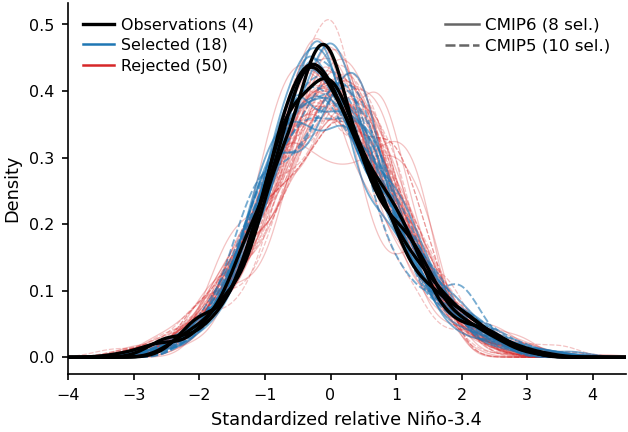

In [17]:
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D

LS = {"CMIP6": "-", "CMIP5": (0, (4, 1.5))}      # solid vs dashed
xg = np.linspace(-4, 5, 500)

fig, ax = plt.subplots(figsize=(SINGLE_COL*1.25, 78*MM))
for m, s in model_rel.items():
    if m in gate: continue
    ax.plot(xg, gaussian_kde(s)(xg), color="tab:red", lw=0.6, alpha=0.28,
            ls=LS[MODELS[m]["gen"]], zorder=1)
for m in gate:
    ax.plot(xg, gaussian_kde(model_rel[m])(xg), color="tab:blue", lw=0.9, alpha=0.6,
            ls=LS[MODELS[m]["gen"]], zorder=2)
for s in obs_rel.values():
    ax.plot(xg, gaussian_kde(s)(xg), color="k", lw=1.6, zorder=3)

n6 = sum(MODELS[m]["gen"] == "CMIP6" for m in gate)
leg1 = ax.legend(handles=[
    Line2D([0],[0], color="k",        lw=1.6, label=f"Observations ({len(obs_rel)})"),
    Line2D([0],[0], color="tab:blue", lw=1.2, label=f"Selected ({len(gate)})"),
    Line2D([0],[0], color="tab:red",  lw=1.2, label=f"Rejected ({len(model_rel)-len(gate)})"),
], frameon=False, loc="upper left")
ax.add_artist(leg1)
ax.legend(handles=[
    Line2D([0],[0], color="0.4", lw=1.2, ls=LS["CMIP6"], label=f"CMIP6 ({n6} sel.)"),
    Line2D([0],[0], color="0.4", lw=1.2, ls=LS["CMIP5"], label=f"CMIP5 ({len(gate)-n6} sel.)"),
], frameon=False, loc="upper right", fontsize=8)

ax.set_xlabel("Standardized relative Ni\u00f1o-3.4"); ax.set_ylabel("Density")
ax.set_xlim(-4, 4.5); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()

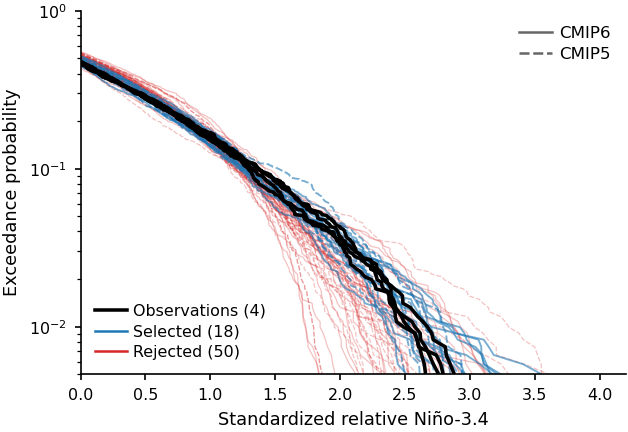

In [18]:
def survival(s):
    x = np.sort(s)
    return x, 1 - np.arange(1, len(x)+1)/(len(x)+1)

fig, ax = plt.subplots(figsize=(SINGLE_COL*1.25, 78*MM))
for m, s in model_rel.items():
    if m in gate: continue
    x, p = survival(s)
    ax.plot(x, p, color="tab:red", lw=0.6, alpha=0.28, ls=LS[MODELS[m]["gen"]], zorder=1)
for m in gate:
    x, p = survival(model_rel[m])
    ax.plot(x, p, color="tab:blue", lw=0.9, alpha=0.6, ls=LS[MODELS[m]["gen"]], zorder=2)
for s in obs_rel.values():
    x, p = survival(s); ax.plot(x, p, color="k", lw=1.7, zorder=3)

ax.set_yscale("log"); ax.set_xlim(0, 4.2); ax.set_ylim(5e-3, 1)
ax.set_xlabel("Standardized relative Ni\u00f1o-3.4"); ax.set_ylabel("Exceedance probability")
leg1 = ax.legend(handles=[
    Line2D([0],[0], color="k",        lw=1.7, label=f"Observations ({len(obs_rel)})"),
    Line2D([0],[0], color="tab:blue", lw=1.2, label=f"Selected ({len(gate)})"),
    Line2D([0],[0], color="tab:red",  lw=1.2, label=f"Rejected ({len(model_rel)-len(gate)})"),
], frameon=False, loc="lower left")
ax.add_artist(leg1)
ax.legend(handles=[
    Line2D([0],[0], color="0.4", lw=1.2, ls=LS["CMIP6"], label="CMIP6"),
    Line2D([0],[0], color="0.4", lw=1.2, ls=LS["CMIP5"], label="CMIP5"),
], frameon=False, loc="upper right", fontsize=8)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()

In [19]:
import dask

# ============================ CONFIGURATION ============================
BASE  = slice("1991", "2020")     # WMO normal - same for models, obs and forecast
CUR   = slice("2000", "2050")     # current-climate sample
# CALIB = slice("1900", "2000")     # amplitude-matching period (inside historical for both MIPs)
N34   = dict(lat=slice(-5, 5),   lon=slice(190, 240))
TRP   = dict(lat=slice(-20, 20), lon=slice(0, 360))



def open_ts(files, period=None):
    """Robust open: handles overlapping / non-monotonic file coverage (common in CMIP5)."""
    ds = xr.open_mfdataset(sorted(files), combine="nested", concat_dim="time",
                           use_cftime=True, chunks={"time": 600},
                           coords="minimal", data_vars="minimal", compat="override")
    da = std_coords(ds).sortby("time")
    da = da.sel(time=~da.indexes["time"].duplicated())
    return da.sel(time=period) if period else da


def area_mean(da, box, ocean=None):
    """Cosine-weighted area mean, optionally ocean-masked."""
    b = da.sel(**box)
    if ocean is not None: b = b.where(ocean.sel(lat=box["lat"]))
    return b.weighted(np.cos(np.deg2rad(b.lat))).mean(("lat", "lon"), skipna=True)


def series(files, period=None):
    """Nino-3.4 and ocean-masked tropical mean, computed in ONE dask pass."""
    da = open_ts(files, period)
    ocean = np.isnan(_LAND.mask(da.lon, da.lat))
    n34 = area_mean(da, N34)
    trp = area_mean(da, TRP, ocean)
    n34, trp = dask.compute(n34, trp)          # single graph traversal, shared reads
    return n34, trp

def indices(n34, trp, clim=None):
    """ONI and RONI. `clim` passes an EXTERNAL monthly climatology - needed for
    piControl, which must share the 1991-2020 reference so the cold offset survives."""
    cn, ct = clim if clim is not None else (
        n34.sel(time=BASE).groupby("time.month").mean("time"),
        trp.sel(time=BASE).groupby("time.month").mean("time"))
    n34a = n34.groupby("time.month") - cn
    trpa = trp.groupby("time.month") - ct
    return (n34a.rolling(time=3, center=True).mean(),
            (n34a - trpa).rolling(time=3, center=True).mean(), (cn, ct))

def event_peaks(idx, min_months=12):
    """Annual block maxima: one peak per COMPLETE ENSO year (Jul-Jun)."""
    idx = idx.dropna("time")
    yr  = idx["time"].dt.year.values
    eyr = np.where(idx["time"].dt.month.values >= 7, yr, yr - 1)
    g   = pd.Series(idx.values, index=eyr).groupby(level=0)
    return g.max()[g.size() >= min_months].values

In [20]:
def obs_indices(name):
    da  = std_obs(open_obs(name))
    n34 = area_mean(da, N34); trp = area_mean(da, TRP)
    oni, rel, _ = indices(n34, trp)
    return oni.compute(), (rel * float(oni.std())/float(rel.std())).compute()

oi = {n: obs_indices(n) for n in obs_files}
SIGMA_OBS = float(np.mean([float(o.sel(time=CALIB).std()) for o, r in oi.values()]))

def peak_in(s, yr): return float(s.sel(time=slice(f"{yr}-07", f"{yr+1}-06")).max())
EVENTS  = [1982, 1997, 2015]
obs_thr = {k: {y: np.mean([peak_in(v[i], y) for v in oi.values()]) for y in EVENTS}
           for i, k in enumerate(["ONI", "RONI"])}

import json
f2026 = json.load(open("/g/data/if69/as8561/data/f2026_roni_forecast.json"))
lab = {y: f"{y}-{str(y+1)[-2:]}" for y in EVENTS}
thresholds = {"ONI":  {lab[y]: obs_thr["ONI"][y] for y in EVENTS},
              "RONI": {**{lab[y]: obs_thr["RONI"][y] for y in EVENTS},
                       "2026-27 fcst": f2026["best"]}}
print(f"SIGMA_OBS = {SIGMA_OBS:.3f}\n"); print(pd.DataFrame(obs_thr).round(2).to_string())

SIGMA_OBS = 0.789

       ONI  RONI
1982  2.22  2.65
1997  2.39  2.42
2015  2.62  2.48


In [30]:
peaks  = {"ONI": {}, "RONI": {}}
factor = {"ONI": {}, "RONI": {}}

for m in tqdm(gate, desc="models"):
    v = MODELS[m]
    try:
        # current climate: historical + scenario spliced, anomalies vs 1991-2020
        cur_files = v["hist"] + files_in_range(v["scen"], 1991, 2050)   # skip 2051-2100
        n34, trp  = series(cur_files)
        oni, rel, clim = indices(n34, trp)
        fo = SIGMA_OBS/float(oni.sel(time=CALIB).std())
        fr = SIGMA_OBS/float(rel.sel(time=CALIB).std())

        # counterfactual: piControl, anomalised against the SAME 1991-2020 climatology
        n34p, trpp = series(v["pic"])
        onip, relp, _ = indices(n34p, trpp, clim=clim)

        factor["ONI"][m], factor["RONI"][m] = fo, fr
        peaks["ONI"][m]  = dict(PI=event_peaks(onip*fo), CUR=event_peaks(oni.sel(time=CUR)*fo))
        peaks["RONI"][m] = dict(PI=event_peaks(relp*fr), CUR=event_peaks(rel.sel(time=CUR)*fr))
    except Exception as e:
        tqdm.write(f" -> {m} SKIP {type(e).__name__}: {str(e)[:60]}")

for k in peaks:
    peaks[k] = {m: d for m, d in peaks[k].items() if len(d["PI"]) and len(d["CUR"])}
print(f"\n{len(peaks['RONI'])} models | PI {sum(len(d['PI']) for d in peaks['RONI'].values())} yr"
      f" | CUR {sum(len(d['CUR']) for d in peaks['RONI'].values())} yr")
print("\namplitude factors (RONI):")
print(pd.Series(factor["RONI"]).round(2).sort_values().to_string())

# sanity: piControl must sit below current
print("\nmean peak RONI:")
for m, d in peaks["RONI"].items():
    print(f"  {m:22s} PI {d['PI'].mean():+.2f}   CUR {d['CUR'].mean():+.2f}")

models:   0%|          | 0/18 [00:00<?, ?it/s]

models: 100%|██████████| 18/18 [04:11<00:00, 13.96s/it]


18 models | PI 10249 yr | CUR 885 yr

amplitude factors (RONI):
GFDL-ESM2M          0.64
bcc-csm1-1-m        0.73
CESM2-WACCM         0.81
CCSM4               0.87
MRI-ESM2-0          0.93
MIROC6              0.99
FIO-ESM-2-0         1.00
CNRM-CM5            1.04
EC-Earth3-Veg-LR    1.22
IPSL-CM5A-MR        1.26
EC-Earth3           1.32
MPI-ESM1-2-LR       1.33
NESM3               1.41
MIROC4h             1.42
CMCC-CM             1.47
GISS-E2-R           1.72
MIROC-ESM-CHEM      2.34
MIROC-ESM           2.47

mean peak RONI:
  CESM2-WACCM            PI +0.50   CUR +0.87
  EC-Earth3              PI +0.29   CUR +0.73
  EC-Earth3-Veg-LR       PI +0.46   CUR +0.61
  FIO-ESM-2-0            PI +0.17   CUR +0.64
  MIROC6                 PI +0.35   CUR +0.65
  MPI-ESM1-2-LR          PI +0.38   CUR +0.54
  MRI-ESM2-0             PI +0.45   CUR +0.58
  NESM3                  PI +0.67   CUR +0.59
  CCSM4                  PI +0.41   CUR +0.45
  CMCC-CM                PI +0.76   CUR +0.82
  CNRM-C

In [22]:
from scipy.stats import genextreme as gev


def pool(pk, sel=None, rng=None, cap=500):
    """Pool annual peaks. Each model contributes at most `cap` piControl years,
    so long runs don't dominate, but short runs don't throttle everyone else."""
    sel = sel if sel is not None else list(pk)
    rng = rng or np.random.default_rng(0)
    pi  = np.concatenate([rng.choice(pk[m]["PI"], min(len(pk[m]["PI"]), cap), replace=False)
                          for m in sel])
    return pi, np.concatenate([pk[m]["CUR"] for m in sel])


def attribute(pk, thrs, n_boot=1000, seed=0, cap=500):
    """PR = P_current/P_preindustrial and dI = intensity change at fixed rarity.
    Uncertainty from a MODEL-block bootstrap (structural spread dominates)."""
    ms  = list(pk)
    rng = np.random.default_rng(seed)
    pi, cur = pool(pk, ms, rng, cap)
    f0, f1  = gev.fit(pi), gev.fit(cur)

    out = {t: dict(RP_PI=1/float(gev.sf(t, *f0)), RP_CUR=1/float(gev.sf(t, *f1)),
                   PR=float(gev.sf(t, *f1))/float(gev.sf(t, *f0)),
                   dI=float(gev.isf(float(gev.sf(t, *f0)), *f1)) - t, b=[]) for t in thrs}
    for _ in range(n_boot):
        s = rng.choice(ms, len(ms), replace=True)
        try:
            a, b = pool(pk, list(s), rng, cap)
            ga, gb = gev.fit(a), gev.fit(b)
        except Exception:
            continue
        for t in thrs:
            p0 = float(gev.sf(t, *ga))
            if p0 > 0: out[t]["b"].append(float(gev.sf(t, *gb))/p0)
    for t in thrs:
        out[t]["lo"], out[t]["hi"] = np.percentile(out[t]["b"], [5, 95])
    return out, (f0, f1), (pi, cur)


In [23]:
print({m: min(len(d["PI"]), 500) for m, d in peaks["RONI"].items()})

{'CESM2-WACCM': 498, 'EC-Earth3': 500, 'EC-Earth3-Veg-LR': 500, 'FIO-ESM-2-0': 499, 'MIROC6': 500, 'MPI-ESM1-2-LR': 500, 'MRI-ESM2-0': 500, 'NESM3': 499, 'CCSM4': 500, 'CMCC-CM': 329, 'CNRM-CM5': 500, 'GFDL-ESM2M': 499, 'GISS-E2-R': 500, 'IPSL-CM5A-MR': 299, 'MIROC-ESM': 500, 'MIROC-ESM-CHEM': 254, 'MIROC4h': 99, 'bcc-csm1-1-m': 399}


In [24]:
K    = "RONI"
thrs = dict(sorted(thresholds[K].items(), key=lambda kv: kv[1]))
res, gfits, samples = attribute(peaks[K], list(thrs.values()))

print(f"{K}: {len(peaks[K])} models | PI n={len(samples[0])}, CUR n={len(samples[1])}\n")
print(f"{'event':14s} {'thr':>5s} {'RP_PI':>7s} {'RP_CUR':>7s} {'PR':>7s} {'[5-95%]':>15s} {'dI':>7s}")
for name, t in thrs.items():
    r  = res[t]
    ci = f"[{r['lo']:.1f}-{r['hi']:.1f}]"
    print(f"  {name:12s} {t:5.2f} {r['RP_PI']:7.0f} {r['RP_CUR']:7.0f} "
          f"{r['PR']:7.1f} {ci:>15s} {r['dI']:+7.2f}")

RONI: 18 models | PI n=7875, CUR n=885

event            thr   RP_PI  RP_CUR      PR         [5-95%]      dI
  1997-98       2.42     253      48     5.3       [3.0-9.5]   +0.61
  2015-16       2.48     309      55     5.6      [3.1-10.4]   +0.61
  1982-83       2.65     610      87     7.0      [3.5-15.3]   +0.64
  2026-27 fcst  3.16    6640     385    17.3      [5.2-87.1]   +0.72


Pre-industrial (piControl)     KS D=0.023
Current 2000–2050              KS D=0.030


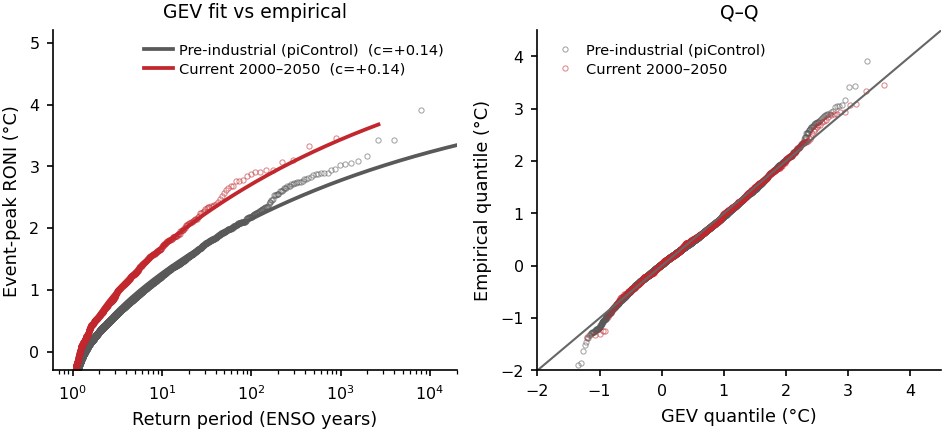

In [25]:
from scipy.stats import kstest, genpareto

STY = [("PI", "Pre-industrial (piControl)", "0.35"),
       ("CUR", "Current 2000\u20132050", "#c1272d")]
samp = {"PI": samples[0], "CUR": samples[1]}

fig, axes = plt.subplots(1, 2, figsize=(DOUBLE_COL*0.9, 78*MM))

ax = axes[0]                                              # return-level: fit vs empirical
for lbl, name, col in STY:
    x  = samp[lbl]; xs = np.sort(x)[::-1]
    rp = (len(xs)+1)/np.arange(1, len(xs)+1)
    ax.plot(rp, xs, "o", ms=2.5, mfc="none", mec=col, mew=0.5, alpha=0.55, zorder=2)
    f  = gev.fit(x)
    pg = np.logspace(np.log10(1/(len(xs)*3)), np.log10(0.6), 200)
    ax.plot(1/pg, gev.isf(pg, *f), "-", color=col, lw=1.8, label=f"{name}  (c={f[0]:+.2f})")
ax.set_xscale("log"); ax.set_xlim(0, 2e4); ax.set_ylim(-0.3, 5.2)
ax.set_xlabel("Return period (ENSO years)"); ax.set_ylabel("Event-peak RONI (\u00b0C)")
ax.set_title("GEV fit vs empirical", fontsize=9); ax.legend(fontsize=7, frameon=False)

ax = axes[1]                                              # Q-Q
for lbl, name, col in STY:
    x = np.sort(samp[lbl]); f = gev.fit(x)
    pp = (np.arange(1, len(x)+1) - 0.5)/len(x)
    ax.plot(gev.ppf(pp, *f), x, "o", ms=2.5, mfc="none", mec=col, mew=0.5, alpha=0.55, label=name)
    print(f"{name:30s} KS D={kstest(x, lambda q: gev.cdf(q, *f)).statistic:.3f}")
lims = [-2.0, 4.5]; ax.plot(lims, lims, "-", color="0.4", lw=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("GEV quantile (\u00b0C)"); ax.set_ylabel("Empirical quantile (\u00b0C)")
ax.set_title("Q\u2013Q", fontsize=9); ax.legend(fontsize=7, frameon=False)
for a in axes: a.spines[["top","right"]].set_visible(False)
plt.tight_layout()

In [26]:
from scipy.stats import genpareto

def gpd_fit(x, q=0.90):
    """Peaks-over-threshold GPD. Returns (survival function, params)."""
    u    = np.quantile(x, q)
    exc  = x[x > u] - u
    c, _, s = genpareto.fit(exc, floc=0)
    zeta = len(exc)/len(x)                       # P(X > u), empirical
    sf   = lambda v: zeta*genpareto.sf(np.asarray(v, float) - u, c, loc=0, scale=s)
    return sf, dict(u=u, c=c, s=s, zeta=zeta, n_exc=len(exc))

print(f"{'q':>5s}  {'sample':28s} {'u':>6s} {'c':>7s} {'scale':>7s} {'n_exc':>6s}")
for q in (0.70, 0.80, 0.85, 0.90, 0.95):
    for lbl, name, _ in STY:
        _, p = gpd_fit(samp[lbl], q)
        print(f"{q:5.2f}  {name:28s} {p['u']:6.2f} {p['c']:+7.3f} {p['s']:7.3f} {p['n_exc']:6d}")

    q  sample                            u       c   scale  n_exc
 0.70  Pre-industrial (piControl)     0.65  -0.106   0.551   2363
 0.70  Current 2000–2050              1.02  -0.183   0.688    266
 0.80  Pre-industrial (piControl)     0.87  -0.103   0.525   1575
 0.80  Current 2000–2050              1.27  -0.231   0.693    177
 0.85  Pre-industrial (piControl)     1.03  -0.087   0.493   1182
 0.85  Current 2000–2050              1.47  -0.197   0.612    133
 0.90  Pre-industrial (piControl)     1.23  -0.081   0.470    788
 0.90  Current 2000–2050              1.69  -0.262   0.628     89
 0.95  Pre-industrial (piControl)     1.54  -0.094   0.456    394
 0.95  Current 2000–2050              2.07  -0.354   0.600     45


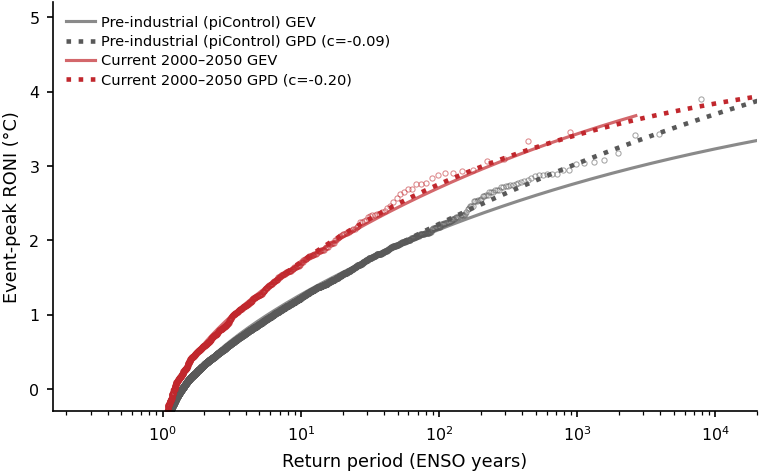

In [27]:
fig, ax = plt.subplots(figsize=(SINGLE_COL*1.5, 85*MM))
Q = 0.85                                          # pick after the sensitivity table
for lbl, name, col in STY:
    x  = samp[lbl]; xs = np.sort(x)[::-1]
    ax.plot((len(xs)+1)/np.arange(1, len(xs)+1), xs, "o", ms=2.5,
            mfc="none", mec=col, mew=0.5, alpha=0.55, zorder=2)
    pg = np.logspace(np.log10(1/(len(xs)*3)), np.log10(0.6), 200)
    ax.plot(1/pg, gev.isf(pg, *gev.fit(x)), "-", color=col, lw=1.5, alpha=0.7,
            label=f"{name} GEV")
    sf, p = gpd_fit(x, Q)
    grid = np.linspace(p["u"], x.max()*1.5, 400)
    ax.plot(1/sf(grid), grid, ":", color=col, lw=2.2, label=f"{name} GPD (c={p['c']:+.2f})")
ax.set_xscale("log"); ax.set_xlim(0, 2e4); ax.set_ylim(-0.3, 5.2)
ax.set_xlabel("Return period (ENSO years)"); ax.set_ylabel("Event-peak RONI (\u00b0C)")
ax.legend(fontsize=7, frameon=False, loc="upper left")
ax.spines[["top","right"]].set_visible(False); plt.tight_layout()

In [28]:
def attribute_gpd(pk, thrs, q=0.85, n_boot=1000, seed=0, cap=500):
    ms  = list(pk)
    rng = np.random.default_rng(seed)
    pi, cur = pool(pk, ms, rng, cap)
    sf0, p0 = gpd_fit(pi, q); sf1, p1 = gpd_fit(cur, q)

    def rl(sf, prob, lo=0.5, hi=8.0):             # invert the survival function
        g = np.linspace(lo, hi, 20000)
        return float(np.interp(-prob, -sf(g), g))

    out = {t: dict(RP_PI=1/float(sf0(t)), RP_CUR=1/float(sf1(t)),
                   PR=float(sf1(t))/float(sf0(t)),
                   dI=rl(sf1, float(sf0(t))) - t, b=[]) for t in thrs}
    for _ in range(n_boot):
        s = rng.choice(ms, len(ms), replace=True)
        try:
            a, b = pool(pk, list(s), rng, cap)
            ga, _ = gpd_fit(a, q); gb, _ = gpd_fit(b, q)
        except Exception:
            continue
        for t in thrs:
            v0 = float(ga(t))
            if v0 > 0: out[t]["b"].append(float(gb(t))/v0)
    for t in thrs:
        out[t]["lo"], out[t]["hi"] = np.percentile(out[t]["b"], [5, 95])
    return out, (p0, p1)

res_g, gpd_params = attribute_gpd(peaks[K], list(thrs.values()), q=Q)
print(f"GPD (q={Q}):  PI c={gpd_params[0]['c']:+.3f} (n_exc={gpd_params[0]['n_exc']}) | "
      f"CUR c={gpd_params[1]['c']:+.3f} (n_exc={gpd_params[1]['n_exc']})\n")
print(f"{'event':14s} {'thr':>5s} {'RP_PI':>7s} {'RP_CUR':>7s} {'PR':>7s} {'[5-95%]':>15s} {'dI':>7s}")
for name, t in thrs.items():
    r  = res_g[t]
    ci = f"[{r['lo']:.1f}-{r['hi']:.1f}]"
    print(f"  {name:12s} {t:5.2f} {r['RP_PI']:7.0f} {r['RP_CUR']:7.0f} "
          f"{r['PR']:7.1f} {ci:>15s} {r['dI']:+7.2f}")

GPD (q=0.85):  PI c=-0.087 (n_exc=1182) | CUR c=-0.197 (n_exc=133)

event            thr   RP_PI  RP_CUR      PR         [5-95%]      dI
  1997-98       2.42     171      43     4.0       [2.4-6.3]   +0.51
  2015-16       2.48     198      49     4.1       [2.4-6.5]   +0.51
  1982-83       2.65     323      76     4.2       [2.4-7.4]   +0.48
  2026-27 fcst  3.16    1497     358     4.2      [1.3-12.9]   +0.35


In [29]:
def gpd_common_shape(x_pi, x_cur, q=0.85):
    """Fit GPD to both samples with a shared shape parameter (fitted on the
    better-constrained pre-industrial tail), scale free in each climate."""
    u0, u1 = np.quantile(x_pi, q), np.quantile(x_cur, q)
    e0, e1 = x_pi[x_pi > u0] - u0, x_cur[x_cur > u1] - u1
    c, _, _ = genpareto.fit(e0, floc=0)                  # shape from piControl
    _, _, s0 = genpareto.fit(e0, floc=0, f0=c)
    _, _, s1 = genpareto.fit(e1, floc=0, f0=c)           # scale only, shape fixed
    z0, z1 = len(e0)/len(x_pi), len(e1)/len(x_cur)
    return (lambda v: z0*genpareto.sf(np.asarray(v,float)-u0, c, loc=0, scale=s0),
            lambda v: z1*genpareto.sf(np.asarray(v,float)-u1, c, loc=0, scale=s1),
            dict(c=c, s0=s0, s1=s1))

In [30]:
# Is the shape difference real, or small-sample noise in the current climate?
rng = np.random.default_rng(0)
ms  = list(peaks[K])
cs  = {"PI": [], "CUR": []}
for _ in range(500):
    s = rng.choice(ms, len(ms), replace=True)
    a, b = pool(peaks[K], list(s), rng, cap=500)
    for lbl, x in (("PI", a), ("CUR", b)):
        try:
            _, p = gpd_fit(x, Q); cs[lbl].append(p["c"])
        except Exception: pass
for lbl in cs:
    v = np.array(cs[lbl])
    print(f"{lbl:4s} c = {np.median(v):+.3f}  [5-95%: {np.percentile(v,5):+.3f}, "
          f"{np.percentile(v,95):+.3f}]")
d = np.array(cs["CUR"]) - np.array(cs["PI"][:len(cs["CUR"])])
print(f"\ndifference (CUR-PI): {np.median(d):+.3f}  "
      f"[{np.percentile(d,5):+.3f}, {np.percentile(d,95):+.3f}]  "
      f"-> {'significant' if np.percentile(d,95) < 0 else 'NOT significant'}")

PI   c = -0.102  [5-95%: -0.156, -0.057]
CUR  c = -0.221  [5-95%: -0.337, -0.100]

difference (CUR-PI): -0.117  [-0.243, +0.021]  -> NOT significant


In [31]:

def gpd_pair(x_pi, x_cur, q=0.85):
    """GPD fitted to both samples with a SHARED shape parameter.
    Shape is estimated on the pre-industrial tail (far better constrained:
    ~1200 exceedances vs ~130); only the scale is free in each climate.
    Justified because the fitted shapes are statistically indistinguishable."""
    u0, u1 = np.quantile(x_pi, q), np.quantile(x_cur, q)
    e0, e1 = x_pi[x_pi > u0] - u0, x_cur[x_cur > u1] - u1
    c, _, s0 = genpareto.fit(e0, floc=0)                  # shape from piControl
    _, _, s1 = genpareto.fit(e1, floc=0, f0=c)            # scale only, shape fixed
    z0, z1   = len(e0)/len(x_pi), len(e1)/len(x_cur)
    sf0 = lambda v: z0*genpareto.sf(np.asarray(v, float) - u0, c, loc=0, scale=s0)
    sf1 = lambda v: z1*genpareto.sf(np.asarray(v, float) - u1, c, loc=0, scale=s1)
    return sf0, sf1, dict(c=c, s0=s0, s1=s1, u0=u0, u1=u1,
                          n0=len(e0), n1=len(e1))

def attribute_common(pk, thrs, q=0.85, n_boot=1000, seed=0, cap=500):
    ms  = list(pk)
    rng = np.random.default_rng(seed)
    pi, cur = pool(pk, ms, rng, cap)
    sf0, sf1, par = gpd_pair(pi, cur, q)

    def rl(sf, prob, lo=0.5, hi=8.0):
        g = np.linspace(lo, hi, 20000)
        return float(np.interp(-prob, -sf(g), g))

    out = {t: dict(RP_PI=1/float(sf0(t)), RP_CUR=1/float(sf1(t)),
                   PR=float(sf1(t))/float(sf0(t)),
                   dI=rl(sf1, float(sf0(t))) - t, b=[]) for t in thrs}
    for _ in range(n_boot):
        s = rng.choice(ms, len(ms), replace=True)
        try:
            a, b = pool(pk, list(s), rng, cap)
            g0, g1, _ = gpd_pair(a, b, q)
        except Exception:
            continue
        for t in thrs:
            v0 = float(g0(t))
            if v0 > 0: out[t]["b"].append(float(g1(t))/v0)
    for t in thrs:
        out[t]["lo"], out[t]["hi"] = np.percentile(out[t]["b"], [5, 95])
    return out, par

res_c, par = attribute_common(peaks[K], list(thrs.values()), q=Q)
print(f"common-shape GPD (q={Q}): c={par['c']:+.3f} | "
      f"scale PI {par['s0']:.3f} (n={par['n0']}), CUR {par['s1']:.3f} (n={par['n1']})\n")
print(f"{'event':14s} {'thr':>5s} {'RP_PI':>7s} {'RP_CUR':>7s} {'PR':>7s} {'[5-95%]':>15s} {'dI':>7s}")
for name, t in thrs.items():
    r  = res_c[t]
    ci = f"[{r['lo']:.1f}-{r['hi']:.1f}]"
    print(f"  {name:12s} {t:5.2f} {r['RP_PI']:7.0f} {r['RP_CUR']:7.0f} "
          f"{r['PR']:7.1f} {ci:>15s} {r['dI']:+7.2f}")

common-shape GPD (q=0.85): c=-0.087 | scale PI 0.493 (n=1182), CUR 0.547 (n=133)

event            thr   RP_PI  RP_CUR      PR         [5-95%]      dI
  1997-98       2.42     171      44     3.9       [2.5-5.9]   +0.59
  2015-16       2.48     198      49     4.0       [2.5-6.2]   +0.60
  1982-83       2.65     323      73     4.4       [2.6-7.3]   +0.62
  2026-27 fcst  3.16    1497     242     6.2      [3.1-15.2]   +0.67


Pre-industrial (piControl)     KS D=0.015  p=0.936
Current 2000–2050              KS D=0.034  p=0.997


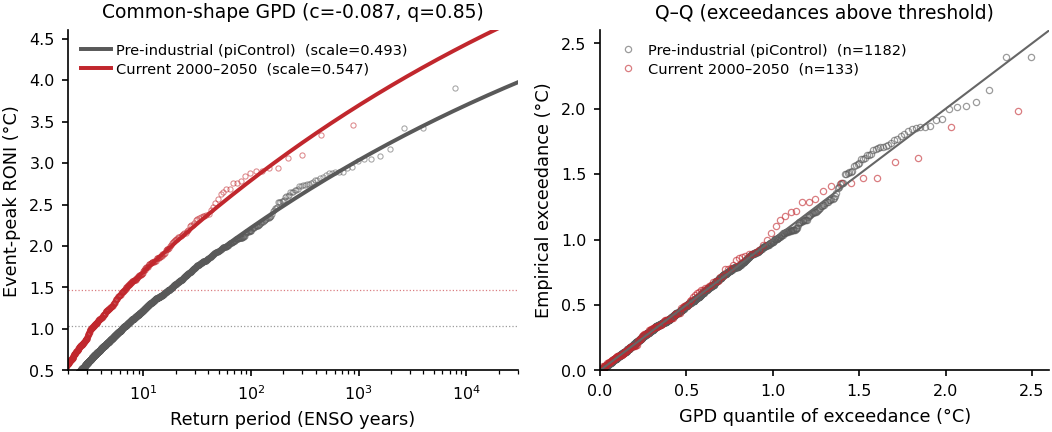

In [32]:
from scipy.stats import genpareto, kstest

# refit on the pooled samples (same call the attribution uses)
pi, cur = pool(peaks[K], None, np.random.default_rng(0), cap=500)
sf0, sf1, par = gpd_pair(pi, cur, Q)
samp = {"PI": pi, "CUR": cur}
STY  = [("PI", "Pre-industrial (piControl)", "0.35"),
        ("CUR", "Current 2000\u20132050", "#c1272d")]
SF   = {"PI": sf0, "CUR": sf1}
U    = {"PI": par["u0"], "CUR": par["u1"]}
SC   = {"PI": par["s0"], "CUR": par["s1"]}

fig, axes = plt.subplots(1, 2, figsize=(DOUBLE_COL*1.0, 78*MM))

# --- (a) return level: empirical points vs common-shape GPD ---
ax = axes[0]
for lbl, name, col in STY:
    x  = samp[lbl]; xs = np.sort(x)[::-1]
    rp = (len(xs)+1)/np.arange(1, len(xs)+1)
    ax.plot(rp, xs, "o", ms=2.5, mfc="none", mec=col, mew=0.5, alpha=0.55, zorder=2)
    grid = np.linspace(U[lbl], x.max()*1.5, 500)          # GPD is only valid above u
    ax.plot(1/SF[lbl](grid), grid, "-", color=col, lw=1.9, zorder=3,
            label=f"{name}  (scale={SC[lbl]:.3f})")
    ax.axhline(U[lbl], color=col, lw=0.6, ls=":", alpha=0.6, zorder=1)
ax.set_xscale("log"); ax.set_xlim(2, 3e4); ax.set_ylim(0.5, 4.6)
ax.set_xlabel("Return period (ENSO years)"); ax.set_ylabel("Event-peak RONI (\u00b0C)")
ax.set_title(f"Common-shape GPD (c={par['c']:+.3f}, q={Q})", fontsize=9)
ax.legend(fontsize=7, frameon=False, loc="upper left")

# --- (b) Q-Q of exceedances (the quantity actually fitted) ---
ax = axes[1]
lims = [0, 2.6]
for lbl, name, col in STY:
    x   = samp[lbl]
    exc = np.sort(x[x > U[lbl]] - U[lbl])
    pp  = (np.arange(1, len(exc)+1) - 0.5)/len(exc)
    q_t = genpareto.ppf(pp, par["c"], loc=0, scale=SC[lbl])
    ax.plot(q_t, exc, "o", ms=3, mfc="none", mec=col, mew=0.6, alpha=0.6,
            label=f"{name}  (n={len(exc)})")
    ks = kstest(exc, lambda v: genpareto.cdf(v, par["c"], loc=0, scale=SC[lbl]))
    print(f"{name:30s} KS D={ks.statistic:.3f}  p={ks.pvalue:.3f}")
ax.plot(lims, lims, "-", color="0.4", lw=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("GPD quantile of exceedance (\u00b0C)")
ax.set_ylabel("Empirical exceedance (\u00b0C)")
ax.set_title("Q\u2013Q (exceedances above threshold)", fontsize=9)
ax.legend(fontsize=7, frameon=False, loc="upper left")

for a in axes: a.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

In [33]:
def gpd_pair_params(x_pi, x_cur, q=0.85):
    """Common-shape GPD parameters for both climates."""
    u0, u1 = np.quantile(x_pi, q), np.quantile(x_cur, q)
    e0, e1 = x_pi[x_pi > u0] - u0, x_cur[x_cur > u1] - u1
    c, _, s0 = genpareto.fit(e0, floc=0)
    _, _, s1 = genpareto.fit(e1, floc=0, f0=c)
    return dict(c=c, u0=u0, s0=s0, z0=len(e0)/len(x_pi),
                       u1=u1, s1=s1, z1=len(e1)/len(x_cur))

def gsf(v, u, c, s, z):   # survival function
    return z*genpareto.sf(np.asarray(v, float) - u, c, loc=0, scale=s)
def grl(p, u, c, s, z):   # return level (inverse)
    return u + s/c*((np.asarray(p, float)/z)**(-c) - 1)

P = gpd_pair_params(pi, cur, Q)
CL = {"PI": (P["u0"], P["c"], P["s0"], P["z0"]),
      "CUR": (P["u1"], P["c"], P["s1"], P["z1"])}

Pre-industrial (piControl)         RP(forecast 3.16) =    1497 yr
Current 2000–2050 (ssp245/rcp45)   RP(forecast 3.16) =     242 yr


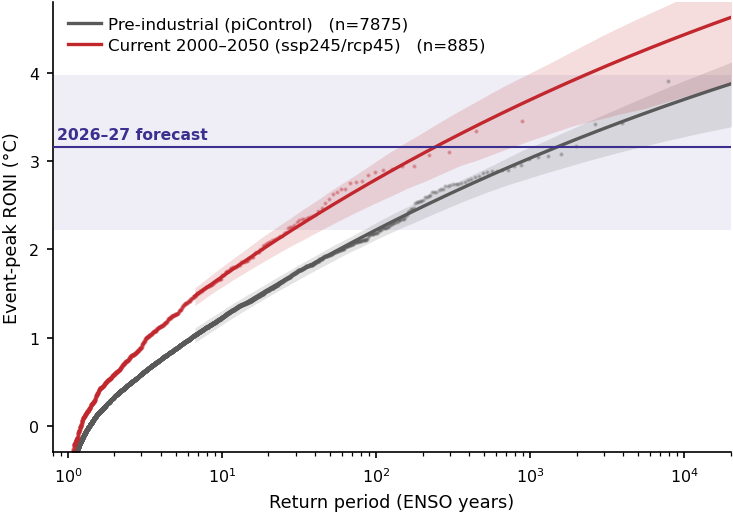

In [34]:
SCEN_LABEL = f"{SCEN6}/{SCEN5}"        # "ssp245/rcp45"


FC  = "#3b2f8f"
STY = [("PI",  "Pre-industrial (piControl)", "0.35"),
       ("CUR", f"Current 2000\u20132050 ({SCEN_LABEL})", "#c1272d")]
rng = np.random.default_rng(0)
ms  = list(peaks[K])

fig, ax = plt.subplots(figsize=(SINGLE_COL*1.45, 92*MM))
ax.axhspan(f2026["low"], f2026["high"], color=FC, alpha=0.08, lw=0, zorder=0)
ax.axhline(f2026["best"], color=FC, lw=1.0, zorder=4)
ax.text(0.85, f2026["best"]+0.06, "2026\u201327 forecast", color=FC,
        fontsize=7.5, fontweight="bold", va="bottom", ha="left")

pg = np.logspace(-4.6, np.log10(0.15), 220)          # probability grid (above threshold)
boot = {"PI": [], "CUR": []}
for _ in range(300):
    s = rng.choice(ms, len(ms), replace=True)
    try:
        a, b = pool(peaks[K], list(s), rng, cap=500)
        p = gpd_pair_params(a, b, Q)
        boot["PI"].append(grl(pg, p["u0"], p["c"], p["s0"], p["z0"]))
        boot["CUR"].append(grl(pg, p["u1"], p["c"], p["s1"], p["z1"]))
    except Exception: pass

for lbl, name, col in STY:
    x  = samp[lbl]
    c_ = np.array(boot[lbl])
    ax.fill_between(1/pg, np.percentile(c_, 5, 0), np.percentile(c_, 95, 0),
                    color=col, alpha=0.16, lw=0, zorder=1)
    xs = np.sort(x)[::-1]
    ax.plot((len(xs)+1)/np.arange(1, len(xs)+1), xs, ".", ms=2,
            color=col, alpha=0.30, zorder=2)
    ax.plot(1/pg, grl(pg, *CL[lbl]), "-", color=col, lw=1.6, zorder=3,
            label=f"{name}   (n={len(x)})")

ax.set_xscale("log"); ax.set_xlim(0.8, 2e4); ax.set_ylim(-0.3, 4.8)
ax.set_xlabel("Return period (ENSO years)"); ax.set_ylabel("Event-peak RONI (\u00b0C)")
ax.legend(loc="upper left", fontsize=8, frameon=False)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()

for lbl, name, _ in STY:
    print(f"{name:34s} RP(forecast {f2026['best']:.2f}) = "
          f"{1/float(gsf(f2026['best'], *CL[lbl])):7.0f} yr")

upper bound becomes infinite at RONI = 4.33 degC


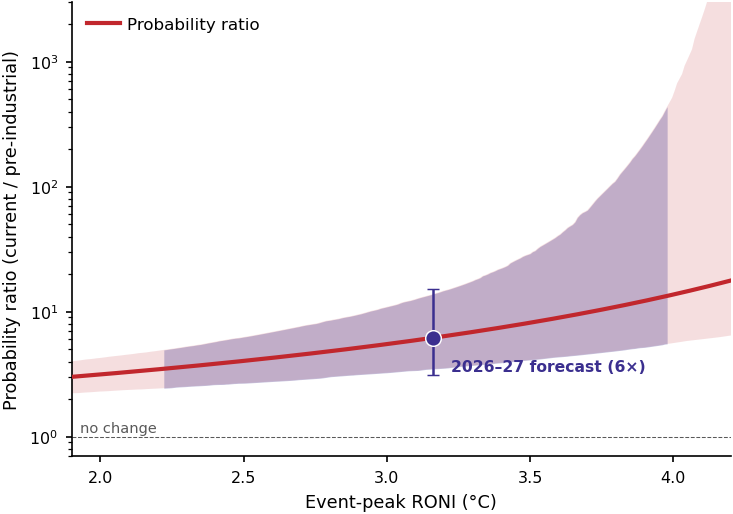

In [35]:
mags = np.linspace(1.9, 4.5, 300)
pr_c = gsf(mags, *CL["CUR"])/gsf(mags, *CL["PI"])

rng, curves = np.random.default_rng(0), []
for _ in range(1000):                       # more samples -> smoother percentiles
    s = rng.choice(ms, len(ms), replace=True)
    try:
        a, b = pool(peaks[K], list(s), rng, cap=500)
        p  = gpd_pair_params(a, b, Q)
        q0 = gsf(mags, p["u0"], p["c"], p["s0"], p["z0"])
        q1 = gsf(mags, p["u1"], p["c"], p["s1"], p["z1"])
        # beyond a bounded pre-industrial tail the ratio is infinite, not missing:
        curves.append(np.where(q0 > 0, q1/np.where(q0 > 0, q0, 1.0), np.inf))
    except Exception:
        pass

C = np.array(curves)                        # constant sample at every magnitude
lo_b = np.percentile(C, 5,  axis=0)
hi_b = np.percentile(C, 95, axis=0)
n_inf = np.isinf(hi_b).sum()
print(f"upper bound becomes infinite at RONI = "
      f"{mags[np.isinf(hi_b)][0]:.2f} degC" if n_inf else "upper bound finite throughout")

fig, ax = plt.subplots(figsize=(SINGLE_COL*1.45, 92*MM))
YTOP = 3e3
hi_plot = np.minimum(hi_b, YTOP*10)         # let it run off the top rather than truncate
ax.fill_between(mags, lo_b, hi_plot, color="#c1272d", alpha=0.15, lw=0, zorder=1)
ax.plot(mags, pr_c, color="#c1272d", lw=2, zorder=4,
        label="Probability ratio")
ax.axhline(1, color="0.35", lw=0.5, ls="--", zorder=2)
ax.text(mags[0]+0.03, 1.03, "no change", fontsize=7, color="0.35", va="bottom")

fb, flo, fhi = f2026["best"], f2026["low"], f2026["high"]
seg = (mags >= flo) & (mags <= fhi)
ax.fill_between(mags[seg], lo_b[seg], hi_plot[seg], color=FC, alpha=0.28, lw=0, zorder=3)

pr_f = float(gsf(fb, *CL["CUR"])/gsf(fb, *CL["PI"]))
rf   = res_c[fb]
# ax.errorbar(fb, pr_f, xerr=[[fb-flo], [fhi-fb]], yerr=[[pr_f-rf["lo"]], [rf["hi"]-pr_f]],
ax.errorbar(fb, pr_f, xerr=None, yerr=[[pr_f-rf["lo"]], [rf["hi"]-pr_f]],
            fmt="o", ms=7.5, color=FC, mec="w", mew=0.7, ecolor=FC,
            capsize=3, lw=1.2, zorder=7)
ax.annotate(f"2026\u201327 forecast ({pr_f:.0f}\u00d7)", (fb, pr_f), xytext=(9, -10),
            textcoords="offset points", fontsize=7.5, color=FC,
            fontweight="bold", ha="left", va="top")

ax.set_yscale("log"); ax.set_xlim(mags[0], 4.2); ax.set_ylim(0.7, YTOP)
ax.set_xlabel("Event-peak RONI (\u00b0C)")
ax.set_ylabel("Probability ratio (current / pre-industrial)")
ax.legend(loc="upper left", fontsize=8, frameon=False)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()

In [36]:
cnt = pd.Series({m: len(d["CUR"]) for m, d in peaks[K].items()}).sort_values()
print(cnt.to_string()); print("total:", cnt.sum())

MIROC4h             35
CESM2-WACCM         50
MIROC-ESM-CHEM      50
MIROC-ESM           50
IPSL-CM5A-MR        50
GISS-E2-R           50
GFDL-ESM2M          50
CNRM-CM5            50
CMCC-CM             50
CCSM4               50
MRI-ESM2-0          50
MPI-ESM1-2-LR       50
MIROC6              50
FIO-ESM-2-0         50
EC-Earth3-Veg-LR    50
EC-Earth3           50
NESM3               50
bcc-csm1-1-m        50
total: 885


In [37]:
print(pd.Series({m: min(len(d["PI"]), 500) for m, d in peaks[K].items()}).sort_values().to_string())

MIROC4h              99
MIROC-ESM-CHEM      254
IPSL-CM5A-MR        299
CMCC-CM             329
bcc-csm1-1-m        399
CESM2-WACCM         498
NESM3               499
FIO-ESM-2-0         499
GFDL-ESM2M          499
MRI-ESM2-0          500
MIROC6              500
CNRM-CM5            500
GISS-E2-R           500
EC-Earth3-Veg-LR    500
MIROC-ESM           500
EC-Earth3           500
MPI-ESM1-2-LR       500
CCSM4               500


## sensitivity analysis

In [38]:
# ---- detrended Nino-3.4: 15-yr high-pass instead of tropical-mean subtraction ----
WIN = 181          # ~15 years of months, odd for a centred window


def detrended_n34(n34):
    """Nino-3.4 anomaly minus its 15-yr running mean, then 3-mon running mean.
    The seasonal climatology is taken from the series itself: the high-pass filter
    removes any constant offset, so the baseline choice has no effect here
    (unlike RONI, where a common baseline is essential)."""
    n34  = n34.assign_coords(month=("time", n34["time"].dt.month.values))
    clim = n34.groupby("month").mean("time")          # own climatology, not BASE
    a    = n34.groupby("month") - clim
    lf   = a.rolling(time=WIN, center=True, min_periods=WIN//2).mean()
    return (a - lf).rolling(time=3, center=True).mean().drop_vars("month", errors="ignore")

peaks_dt, factor_dt = {}, {}
for m in tqdm(gate, desc="detrended"):
    v = MODELS[m]
    try:
        n34c, _ = series(v["hist"] + files_in_range(v["scen"], 1991, 2050))
        n34p, _ = series(v["pic"])
        dc, dp  = detrended_n34(n34c), detrended_n34(n34p)
        f = SIGMA_OBS/float(dc.sel(time=CALIB).std())
        factor_dt[m] = f
        peaks_dt[m]  = dict(PI=event_peaks(dp*f), CUR=event_peaks(dc.sel(time=CUR)*f))
    except Exception as e:
        tqdm.write(f"  {m} SKIP {type(e).__name__}: {str(e)[:50]}")
peaks_dt = {m: d for m, d in peaks_dt.items() if len(d["PI"]) and len(d["CUR"])}

# observed thresholds on the same index
def obs_detrended(name):
    da  = std_obs(open_obs(name))
    return detrended_n34(area_mean(da, N34)).compute()
oi_dt   = {n: obs_detrended(n) for n in obs_files}
thr_dt  = {lab[y]: np.mean([peak_in(s, y) for s in oi_dt.values()]) for y in EVENTS}
print("\ndetrended-Nino3.4 event thresholds:",
      {k: round(v, 2) for k, v in thr_dt.items()})

res_dt, par_dt = attribute_common(peaks_dt, list(thr_dt.values()), q=Q)
print(f"\ncommon-shape GPD: c={par_dt['c']:+.3f} | "
      f"scale PI {par_dt['s0']:.3f}, CUR {par_dt['s1']:.3f} "
      f"(ratio {par_dt['s1']/par_dt['s0']:.3f})\n")
print(f"{'event':14s} {'thr':>5s} {'RP_PI':>7s} {'RP_CUR':>7s} {'PR':>7s} {'[5-95%]':>15s} {'dI':>7s}")
for name, t in thr_dt.items():
    r  = res_dt[t]; ci = f"[{r['lo']:.1f}-{r['hi']:.1f}]"
    print(f"  {name:12s} {t:5.2f} {r['RP_PI']:7.0f} {r['RP_CUR']:7.0f} "
          f"{r['PR']:7.1f} {ci:>15s} {r['dI']:+7.2f}")

detrended:   0%|          | 0/18 [00:00<?, ?it/s]

detrended: 100%|██████████| 18/18 [03:54<00:00, 13.04s/it]



detrended-Nino3.4 event thresholds: {'1982-83': 2.34, '1997-98': 2.3, '2015-16': 2.68}

common-shape GPD: c=-0.087 | scale PI 0.486, CUR 0.531 (ratio 1.092)

event            thr   RP_PI  RP_CUR      PR         [5-95%]      dI
  1982-83       2.34     109      50     2.2       [1.3-3.0]   +0.34
  1997-98       2.30      99      46     2.2       [1.3-3.0]   +0.33
  2015-16       2.68     278     111     2.5       [1.2-3.8]   +0.37


In [39]:
Z = 1 - Q                                   # exceedance rate, identical by construction
def sf_p(v, u, s):  return Z*genpareto.sf(np.asarray(v, float) - u, P["c"], loc=0, scale=s)

print(f"location shift  u1-u0 = {P['u1']-P['u0']:+.3f} degC")
print(f"scale ratio     s1/s0 = {P['s1']/P['s0']:.3f}\n")
print(f"{'event':14s} {'total':>7s} {'loc only':>9s} {'scale only':>11s} {'loc x scale':>12s}")
for name, t in thrs.items():
    base  = sf_p(t, P["u0"], P["s0"])
    tot   = sf_p(t, P["u1"], P["s1"])/base
    loc   = sf_p(t, P["u1"], P["s0"])/base      # CUR location, PI scale
    scl   = sf_p(t, P["u0"], P["s1"])/base      # PI location, CUR scale
    print(f"  {name:12s} {tot:7.2f} {loc:9.2f} {scl:11.2f} {loc*scl:12.2f}")

location shift  u1-u0 = +0.441 degC
scale ratio     s1/s0 = 1.109

event            total  loc only  scale only  loc x scale
  1997-98         3.88      3.09        1.44         4.44
  2015-16         3.99      3.13        1.47         4.59
  1982-83         4.41      3.29        1.56         5.13
  2026-27 fcst    6.18      3.86        1.94         7.48


In [40]:
tfc  = f2026["best"]
t82  = thresholds[K]["1982-83"]
subsets = {
    "all (18)":       list(peaks[K]),
    "CMIP6 only":     [m for m in peaks[K] if MODELS[m]["gen"] == "CMIP6"],
    "CMIP5 only":     [m for m in peaks[K] if MODELS[m]["gen"] == "CMIP5"],
    "no MIROC-ESM*":  [m for m in peaks[K] if not m.startswith("MIROC-ESM")],
    "no MIROC4h":     [m for m in peaks[K] if m != "MIROC4h"],
    "no NESM3":       [m for m in peaks[K] if m != "NESM3"],
}

print(f"{'subset':16s} {'n':>3s} {'PR(fcst)':>9s} {'[5-95%]':>14s} "
      f"{'PR(1982-83)':>12s} {'[5-95%]':>14s}")
for name, sub in subsets.items():
    r, _ = attribute_common({m: peaks[K][m] for m in sub}, [tfc, t82], q=Q, n_boot=500)
    ci_f = f"[{r[tfc]['lo']:.1f}-{r[tfc]['hi']:.1f}]"
    ci_8 = f"[{r[t82]['lo']:.1f}-{r[t82]['hi']:.1f}]"
    print(f"  {name:14s} {len(sub):3d} {r[tfc]['PR']:9.1f} {ci_f:>14s} "
          f"{r[t82]['PR']:12.1f} {ci_8:>14s}")

# leave-one-out: central estimates only
loo = {}
for m in peaks[K]:
    sub = {k: v for k, v in peaks[K].items() if k != m}
    r, _ = attribute_common(sub, [tfc], q=Q, n_boot=100)
    loo[m] = r[tfc]["PR"]
s = pd.Series(loo).sort_values()
print(f"\nleave-one-out PR(forecast): {s.min():.1f} - {s.max():.1f} "
      f"(full ensemble {res_c[tfc]['PR']:.1f})")
print(s.round(2).to_string())

subset             n  PR(fcst)        [5-95%]  PR(1982-83)        [5-95%]
  all (18)        18       6.2     [3.0-15.2]          4.4      [2.6-7.3]
  CMIP6 only       8       6.4     [3.6-14.5]          5.1      [3.1-8.4]
  CMIP5 only      10       5.0     [0.4-44.4]          3.4     [1.1-11.2]
  no MIROC-ESM*   16       5.1     [2.8-12.9]          3.9      [2.4-6.5]
  no MIROC4h      17       6.1     [2.9-13.9]          4.3      [2.5-7.2]
  no NESM3        17       6.5     [2.9-15.5]          4.6      [2.6-7.7]

leave-one-out PR(forecast): 5.1 - 9.2 (full ensemble 6.2)
MIROC-ESM           5.09
CCSM4               5.44
CNRM-CM5            5.82
MRI-ESM2-0          5.92
GISS-E2-R           6.05
MIROC4h             6.07
MIROC6              6.13
bcc-csm1-1-m        6.26
CESM2-WACCM         6.32
EC-Earth3           6.35
MIROC-ESM-CHEM      6.36
GFDL-ESM2M          6.43
IPSL-CM5A-MR        6.48
NESM3               6.51
EC-Earth3-Veg-LR    6.72
CMCC-CM             6.96
FIO-ESM-2-0         8.4

In [41]:
tfc = f2026["best"]
print(f"{'q':>5s} {'n_exc PI':>9s} {'n_exc CUR':>10s} {'PR(fcst)':>9s} {'[5-95%]':>14s}")
for q in (0.75, 0.80, 0.85, 0.90):
    r, p = attribute_common(peaks[K], [tfc], q=q, n_boot=300)
    ci = f"[{r[tfc]['lo']:.1f}-{r[tfc]['hi']:.1f}]"
    print(f"{q:5.2f} {p['n0']:9d} {p['n1']:10d} {r[tfc]['PR']:9.1f} {ci:>14s}")

    q  n_exc PI  n_exc CUR  PR(fcst)        [5-95%]
 0.75      1969        221       7.7     [4.0-16.5]
 0.80      1575        177       7.6     [3.7-16.8]
 0.85      1182        133       6.2     [3.0-14.4]
 0.90       788         89       6.1     [2.6-15.1]


In [ ]:
# ---- recompute once, cache index series so all later diagnostics are instant ----
cache = {}
for m in tqdm(gate, desc="cache"):
    v = MODELS[m]
    try:
        n34c, trpc = series(v["hist"] + files_in_range(v["scen"], 1991, 2050))
        oni, rel, clim = indices(n34c, trpc)
        n34p, trpp = series(v["pic"])
        onip, relp, _ = indices(n34p, trpp, clim=clim)
        cache[m] = dict(n34c=n34c, trpc=trpc, n34p=n34p, trpp=trpp,
                        rel_c=rel.sel(time=CUR), rel_p=relp,
                        oni_c=oni.sel(time=CUR), oni_p=onip)
    except Exception as e:
        tqdm.write(f"  {m} SKIP {type(e).__name__}: {str(e)[:50]}")


cache: 100%|██████████| 18/18 [10:33<00:00, 35.22s/it]


NameError: name 'factor' is not defined

In [31]:
rows = []
for m, d in cache.items():
    f = factor["RONI"][m]
    dn34 = float(d["n34c"].sel(time=CUR).mean()) - float(d["n34p"].mean())
    dtrp = float(d["trpc"].sel(time=CUR).mean()) - float(d["trpp"].mean())
    s_pi, s_cur = float(d["rel_p"].std())*f, float(d["rel_c"].std())*f
    rows.append(dict(model=m, gen=MODELS[m]["gen"],
                     dT_n34=dn34, dT_trop=dtrp, dT_rel=dn34-dtrp,
                     sd_PI=s_pi, sd_CUR=s_cur, sd_ratio=s_cur/s_pi))
D = pd.DataFrame(rows).set_index("model")
print(D.round(3).to_string())
print("\nmulti-model mean:")
print(D[["dT_n34","dT_trop","dT_rel","sd_PI","sd_CUR","sd_ratio"]].mean().round(3).to_string())

                    gen  dT_n34  dT_trop  dT_rel  sd_PI  sd_CUR  sd_ratio
model                                                                    
CESM2-WACCM       CMIP6   1.359    1.184   0.176  0.667   0.965     1.448
EC-Earth3         CMIP6   1.383    1.191   0.193  0.744   1.149     1.544
EC-Earth3-Veg-LR  CMIP6   1.237    1.155   0.082  0.646   0.938     1.452
FIO-ESM-2-0       CMIP6   1.510    1.140   0.370  0.675   0.889     1.317
MIROC6            CMIP6   1.013    0.919   0.094  0.701   1.164     1.659
MPI-ESM1-2-LR     CMIP6   1.009    0.920   0.089  0.806   0.801     0.994
MRI-ESM2-0        CMIP6   1.038    0.910   0.127  0.704   0.782     1.110
NESM3             CMIP6   0.846    0.924  -0.079  0.734   0.821     1.120
CCSM4             CMIP5   1.282    1.175   0.107  0.765   0.640     0.836
CMCC-CM           CMIP5   0.922    0.951  -0.029  0.859   0.938     1.091
CNRM-CM5          CMIP5   1.008    0.906   0.102  0.701   0.759     1.084
GFDL-ESM2M        CMIP5   1.171    1.0

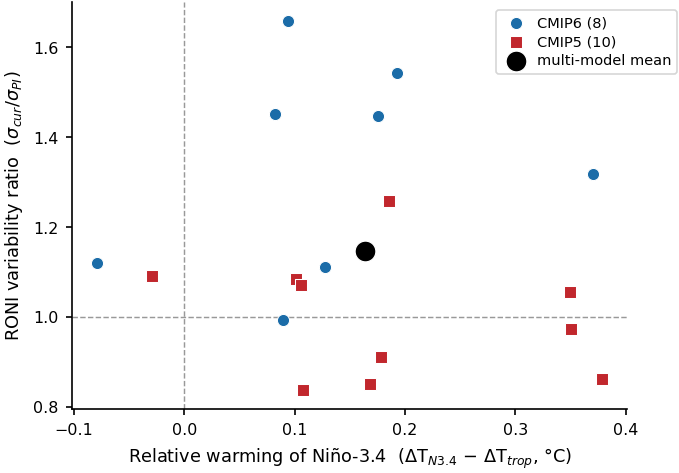

In [38]:
fig, ax = plt.subplots(figsize=(SINGLE_COL*1.35, 85*MM))
for gen, mk, col in [("CMIP6", "o", "#1b6ca8"), ("CMIP5", "s", "#c1272d")]:
    sub = D[D.gen == gen]
    ax.scatter(sub.dT_rel, sub.sd_ratio, marker=mk, s=34, color=col,
               edgecolor="w", lw=0.5, label=f"{gen} ({len(sub)})", zorder=3)
ax.axhline(1, color="0.6", lw=0.7, ls="--", zorder=1)
ax.axvline(0, color="0.6", lw=0.7, ls="--", zorder=1)
ax.scatter(D.dT_rel.mean(), D.sd_ratio.mean(), marker="o", s=100, color="k",
           edgecolor="w", lw=0.6, zorder=4, label="multi-model mean")
# for m, r in D.iterrows():
#     ax.annotate(m, (r.dT_rel, r.sd_ratio), fontsize=5, color="0.45",
#                 xytext=(3, 3), textcoords="offset points")
ax.set_xlabel("Relative warming of Ni\u00f1o-3.4  (\u0394T$_{N3.4}$ \u2212 \u0394T$_{trop}$, \u00b0C)")
ax.set_ylabel("RONI variability ratio  ($\\sigma_{cur}/\\sigma_{PI}$)")
ax.legend(fontsize=7, frameon=True, ncol=1, bbox_to_anchor=(0.75, 1.0)); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig('./images/edf3.png', dpi=300)

In [44]:
rows = []
for name, t in thrs.items():
    r = res_c[t]
    rows.append({
        "event":                    name,
        "threshold (degC)":         round(t, 2),
        "return period, PI (yr)":   round(r["RP_PI"]),
        "return period, current (yr)": round(r["RP_CUR"]),
        "probability ratio":        round(r["PR"], 1),
        "PR 5-95%":                 f"{r['lo']:.1f}-{r['hi']:.1f}",
        "intensity change (degC)":  round(r["dI"], 2),
    })
EDT1 = pd.DataFrame(rows).set_index("event")

note = (f"Common-shape GPD, threshold q={Q}: shape c={par['c']:+.3f}; "
        f"scale {par['s0']:.3f} (pre-industrial, n={par['n0']} exceedances) and "
        f"{par['s1']:.3f} (current, n={par['n1']}); scale ratio {par['s1']/par['s0']:.3f}. "
        f"Pre-industrial from piControl (n={len(samp['PI'])} ENSO years), current from "
        f"historical+{SCEN6}/{SCEN5} 2000-2050 (n={len(samp['CUR'])}), {len(peaks[K])} models. "
        f"Ranges are 5-95% from a model-block bootstrap (1000 resamples).")

print(EDT1.to_string()); print("\n" + note)
EDT1.to_csv("EDT1_attribution.csv")
with open("EDT1_attribution_note.txt", "w") as f:
    f.write(note)

              threshold (degC)  return period, PI (yr)  return period, current (yr)  probability ratio  PR 5-95%  intensity change (degC)
event                                                                                                                                    
1997-98                   2.42                     171                           44                3.9   2.5-5.9                     0.59
2015-16                   2.48                     198                           49                4.0   2.5-6.2                     0.60
1982-83                   2.65                     323                           73                4.4   2.6-7.3                     0.62
2026-27 fcst              3.16                    1497                          242                6.2  3.1-15.2                     0.67

Common-shape GPD, threshold q=0.85: shape c=-0.087; scale 0.493 (pre-industrial, n=1182 exceedances) and 0.547 (current, n=133); scale ratio 1.109. Pre-industrial from piC

In [45]:
EDT2 = pd.DataFrame({
    "generation":   {m: MODELS[m]["gen"] for m in gate},
    "skewness":     {m: round(model_skew[m], 3) for m in gate},
    "amp. factor":  {m: round(factor[K][m], 2) for m in gate},
    "piControl yr": {m: len(peaks[K][m]["PI"]) for m in gate},
    "current yr":   {m: len(peaks[K][m]["CUR"]) for m in gate},
    "dT_rel (K)":   D["dT_rel"].round(3),
    "sigma ratio":  D["sd_ratio"].round(3),
}).sort_values(["generation", "skewness"])
print(EDT2.to_string())
EDT2.to_csv("./data/EDT2_model_ensemble.csv")

                 generation  skewness  amp. factor  piControl yr  current yr  dT_rel (K)  sigma ratio
CNRM-CM5              CMIP5     0.195         1.04           849          50       0.102        1.084
GISS-E2-R             CMIP5     0.198         1.72           848          50       0.379        0.862
MIROC-ESM-CHEM        CMIP5     0.207         2.34           254          50       0.168        0.851
MIROC-ESM             CMIP5     0.237         2.47           629          50       0.351        0.972
bcc-csm1-1-m          CMIP5     0.245         0.73           399          50       0.350        1.055
CMCC-CM               CMIP5     0.273         1.47           329          50      -0.029        1.091
IPSL-CM5A-MR          CMIP5     0.303         1.26           299          50       0.179        0.910
MIROC4h               CMIP5     0.385         1.42            99          35       0.185        1.259
GFDL-ESM2M            CMIP5     0.410         0.64           499          50      

In [49]:
EDT3 = pd.DataFrame([
    dict(test="Main (common-shape GPD, q=0.85)",   PR=6.2,  lo=3.1, hi=15.2),
    dict(test="GPD threshold q=0.75",              PR=7.7,  lo=4.0, hi=16.5),
    dict(test="GPD threshold q=0.80",              PR=7.6,  lo=3.7, hi=16.8),
    dict(test="GPD threshold q=0.90",              PR=6.1,  lo=2.6, hi=15.1),
    dict(test="Independent shapes (not common)",   PR=4.2,  lo=1.3, hi=12.9),
    dict(test="GEV instead of GPD",                PR=17.3, lo=5.2, hi=87.1),
    dict(test="CMIP6 models only (8)",             PR=6.4,  lo=3.6, hi=14.5),
    dict(test="CMIP5 models only (10)",            PR=5.0,  lo=0.4, hi=44.4),
    dict(test="Excluding MIROC-ESM variants (16)", PR=5.1,  lo=2.8, hi=12.9),
    dict(test="Leave-one-out range",               PR=6.2,  lo=5.1, hi=9.2),
]).set_index("test")
print(EDT3.round(1).to_string())
EDT3.to_csv("./data/EDT3_sensitivity.csv")

                                     PR   lo    hi
test                                              
Main (common-shape GPD, q=0.85)     6.2  3.1  15.2
GPD threshold q=0.75                7.7  4.0  16.5
GPD threshold q=0.80                7.6  3.7  16.8
GPD threshold q=0.90                6.1  2.6  15.1
Independent shapes (not common)     4.2  1.3  12.9
GEV instead of GPD                 17.3  5.2  87.1
CMIP6 models only (8)               6.4  3.6  14.5
CMIP5 models only (10)              5.0  0.4  44.4
Excluding MIROC-ESM variants (16)   5.1  2.8  12.9
Leave-one-out range                 6.2  5.1   9.2


In [47]:
print(f2026["obs_record_central"], f2026["prob_exceed_record_pct"], obs_thr["RONI"][1982])

2.65 84.3 2.6549496054649353


In [51]:
f2026

{'best': 3.16,
 'low': 2.22,
 'high': 3.98,
 'cycle': '2026-08',
 'corrected': True,
 'ensmean': True,
 'per_model_corr': {'GEOSS2S': 2.22,
  'CanSIPS-IC4': 3.98,
  'CCSM4': 2.96,
  'CESM1': 3.48},
 'per_model_raw': {'GEOSS2S': 3.94,
  'CanSIPS-IC4': 3.1,
  'CCSM4': 3.1,
  'CESM1': 4.53},
 'obs_record_central': 2.65,
 'obs_record_range': [2.57, 2.82],
 'prob_exceed_record_pct': 84.3,
 'prob_exceed_record_range_pct': [81.4, 87.1],
 'prob_exceed_raw_pct': 94.3,
 'n_members': 70,
 'forecast_median_peak': 3.57}

### check if observations show n34 region warming fastaer than tropics compared to models over the same period

In [21]:
from scipy.stats import linregress

N34_BOX = dict(lat=slice(-5, 5),   lon=slice(190, 240))
TRP_BOX = dict(lat=slice(-20, 20), lon=slice(0, 360))

def _amean(da, box):
    b = da.sel(**box)
    w = np.cos(np.deg2rad(b.lat))
    return b.weighted(w).mean(("lat", "lon"), skipna=True)

def obs_relative_trend(name, period):
    """Annual-mean Nino-3.4, tropical-mean and relative SST, with linear trends."""
    da  = std_obs(open_obs(name)).sel(time=period)
    n34, trp = _amean(da, N34_BOX), _amean(da, TRP_BOX)
    ann = xr.Dataset(dict(n34=n34, trp=trp, rel=n34 - trp)) \
            .groupby("time.year").mean("time").compute()
    out = {}
    for v in ("n34", "trp", "rel"):
        y, t = ann[v].values, ann["year"].values
        ok = np.isfinite(y)
        lr = linregress(t[ok], y[ok])
        out[v] = (lr.slope*100, lr.pvalue)          # degC per century
    return out, ann

PERIODS = {"1900-2025": slice("1900", "2025"),
           "1950-2025": slice("1950", "2025"),
           "1980-2025": slice("1980", "2025")}

print(f"{'period':11s} {'product':9s} {'Nino3.4':>9s} {'tropics':>9s} {'relative':>10s}   (degC/century)")
rel_trends = {}
for pname, per in PERIODS.items():
    for prod in ["COBE", "DCSST", "HadISST", "ERSSTv5"]:
        try:
            tr, _ = obs_relative_trend(prod, per)
            rel_trends[(pname, prod)] = tr["rel"][0]
            star = "*" if tr["rel"][1] < 0.05 else " "
            print(f"  {pname:9s} {prod:9s} {tr['n34'][0]:+9.2f} {tr['trp'][0]:+9.2f} "
                  f"{tr['rel'][0]:+9.2f}{star}")
        except Exception as e:
            print(f"  {pname:9s} {prod:9s} SKIP {type(e).__name__}: {e}")
    print()

period      product     Nino3.4   tropics   relative   (degC/century)
  1900-2025 COBE          +0.15     +0.67     -0.52*
  1900-2025 DCSST         +0.52     +0.65     -0.13 
  1900-2025 HadISST       +0.03     +0.54     -0.50*
  1900-2025 ERSSTv5       +0.53     +0.82     -0.30*

  1950-2025 COBE          +0.45     +1.06     -0.61*
  1950-2025 DCSST         +1.21     +1.27     -0.06 
  1950-2025 HadISST       +0.35     +0.91     -0.55*
  1950-2025 ERSSTv5       +0.64     +1.17     -0.53 

  1980-2025 COBE          -0.07     +1.31     -1.38*
  1980-2025 DCSST         +0.25     +1.17     -0.92 
  1980-2025 HadISST       -0.15     +0.91     -1.06 
  1980-2025 ERSSTv5       -0.09     +1.16     -1.25*



In [25]:
def model_relative_trend(m, period=slice("1950", "2025")):
    files = MODELS[m]["hist"] + MODELS[m]["scen"]
    da  = open_ts(files, period)
    ocean = np.isnan(_LAND.mask(da.lon, da.lat))
    n34 = _amean(da, N34_BOX)
    b   = da.sel(lat=slice(-20, 20)).where(ocean.sel(lat=slice(-20, 20)))
    trp = b.weighted(np.cos(np.deg2rad(b.lat))).mean(("lat", "lon"), skipna=True)
    ann = (n34 - trp).groupby("time.year").mean("time").compute()
    lr  = linregress(ann["year"].values, ann.values)
    return lr.slope*100, lr.pvalue

mod_rel, mod_p = {}, {}
for m in gate:
    mod_rel[m], mod_p[m] = {}, {}
    for pname, per in PERIODS.items():
        try:
            mod_rel[m][pname], mod_p[m][pname] = model_relative_trend(m, per)
        except Exception:
            mod_rel[m][pname], mod_p[m][pname] = np.nan, np.nan

M, P = pd.DataFrame(mod_rel).T, pd.DataFrame(mod_p).T
for p in PERIODS:
    v, pv = M[p].dropna(), P[p].dropna()
    sig_pos = int(((v > 0) & (pv < 0.05)).sum())
    sig_neg = int(((v < 0) & (pv < 0.05)).sum())
    print(f"  {p:11s} positive {int((v>0).sum())}/{len(v)}   "
          f"significant positive {sig_pos}   significant negative {sig_neg}")

  1900-2025   positive 16/18   significant positive 3   significant negative 0
  1950-2025   positive 13/18   significant positive 2   significant negative 0
  1980-2025   positive 13/18   significant positive 0   significant negative 0


In [27]:
M

,1900-2025,1950-2025,1980-2025
CESM2-WACCM,-0.157814,-0.175532,0.229025
EC-Earth3,0.307691,0.345410,0.259936
EC-Earth3-Veg-LR,0.013748,-0.011073,0.416682
FIO-ESM-2-0,0.211503,-0.044762,0.250945
MIROC6,-0.023948,-0.158538,-0.679034
MPI-ESM1-2-LR,0.158530,0.177897,-0.034534
MRI-ESM2-0,0.081760,-0.108913,-0.737940
NESM3,0.009440,0.092662,0.201453
CCSM4,0.134518,0.078753,-0.143066
CMCC-CM,0.079568,0.038203,0.474594


In [28]:
p

'1980-2025'

In [26]:
# mod_rel = {}
# for m in gate:
#     mod_rel[m] = {}
#     for pname, per in PERIODS.items():
#         try:
#             mod_rel[m][pname] = model_relative_trend(m, per)
#         except Exception as e:
#             mod_rel[m][pname] = np.nan
#     print(f"  {m:20s} " + "  ".join(f"{mod_rel[m][p]:+6.2f}" for p in PERIODS))

# M = pd.DataFrame(mod_rel).T
# print("\nmodel summary (degC/century):")
# for p in PERIODS:
#     v = M[p].dropna()
#     print(f"  {p:11s} mean {v.mean():+.2f}   range {v.min():+.2f} to {v.max():+.2f}"
#           f"   positive {int((v>0).sum())}/{len(v)}")